In [2]:
import importlib_resources
import numpy as np
import xlrd
import pandas as pd
from scipy.linalg import svd 
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [3]:
# Load csv file with data
df = pd.read_csv('C:\\Users\\ellas\\Desktop\\DTU\\2.semester\\Machine learning\\projekt 1\\null-corrected (1).csv')

In [4]:
df.head()

,Unnamed: 0,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [5]:
df['chol'] = np.log(df['chol'])
df.head()

,Unnamed: 0,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,0,63.0,1.0,1.0,145.0,5.451038,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,1,67.0,1.0,4.0,160.0,5.655992,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,2,67.0,1.0,4.0,120.0,5.433722,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,3,37.0,1.0,3.0,130.0,5.521461,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,4,41.0,0.0,2.0,130.0,5.318120,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [6]:
# Extract attribute names
attributeNames = df.columns[1:15].tolist()
print(attributeNames)

['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


In [7]:
# Konverter til et numpy-array (dog uden index-kolonne samt target-kolonne) 
X = df.iloc[:, 1:-1].to_numpy()
X

array([[63.,  1.,  1., ...,  3.,  0.,  6.],
       [67.,  1.,  4., ...,  2.,  3.,  3.],
       [67.,  1.,  4., ...,  2.,  2.,  7.],
       ...,
       [57.,  1.,  4., ...,  2.,  1.,  7.],
       [57.,  0.,  2., ...,  2.,  1.,  3.],
       [38.,  1.,  3., ...,  1.,  0.,  3.]])

In [8]:
# Standardisering af data - træk middelværdi fra og divider med standardafvigelse
N = len(X)
X_ = X - np.ones((N, 1)) * X.mean(axis=0)
X_hat = X_ / X.std(axis=0)
X_hat

array([[ 0.94872647,  0.68620244, -2.25177456, ...,  2.27457861,
        -0.71113139,  0.65913253],
       [ 1.39200191,  0.68620244,  0.87798549, ...,  0.64911323,
         2.5048807 , -0.86542592],
       [ 1.39200191,  0.68620244,  0.87798549, ...,  0.64911323,
         1.43287667,  1.16731868],
       ...,
       [ 0.28381332,  0.68620244,  0.87798549, ...,  0.64911323,
         0.36087264,  1.16731868],
       [ 0.28381332, -1.4572959 , -1.20852121, ...,  0.64911323,
         0.36087264, -0.86542592],
       [-1.82174501,  0.68620244, -0.16526786, ..., -0.97635214,
        -0.71113139, -0.86542592]])

In [9]:
# PCA ved at udføre SVD på X_hat
U, S, Vh = svd(X_hat, full_matrices=False)

In [10]:
S

array([30.50114995, 21.96965912, 19.32160324, 18.26028991, 17.34330164,
       16.39233285, 16.21681519, 15.2558311 , 14.50462915, 13.05079704,
       11.87096781, 11.19016887, 10.35277254])

In [11]:
# Beregn variance explained
rho = (S * S) / (S * S).sum()
rho

array([0.23618181, 0.12253514, 0.09477643, 0.08465047, 0.07636205,
       0.06821746, 0.06676443, 0.05908616, 0.05341058, 0.04324024,
       0.03577555, 0.03178976, 0.02720993])

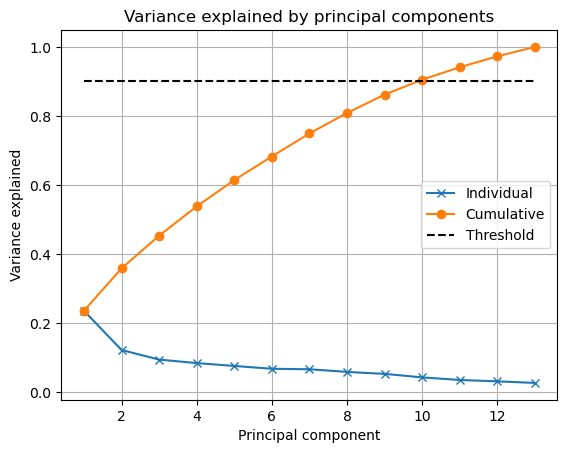

In [12]:
# Plot graf over, hvor mange komponenter der skal bruges for at forklare 95% af variansen
threshold = 0.90

# Plot variance explained
plt.figure()
plt.plot(range(1, len(rho) + 1), rho, "x-")
plt.plot(range(1, len(rho) + 1), np.cumsum(rho), "o-")
plt.plot([1, len(rho)], [threshold, threshold], "k--")
plt.title("Variance explained by principal components")
plt.xlabel("Principal component")
plt.ylabel("Variance explained")
plt.legend(["Individual", "Cumulative", "Threshold"])
plt.grid()
plt.show()

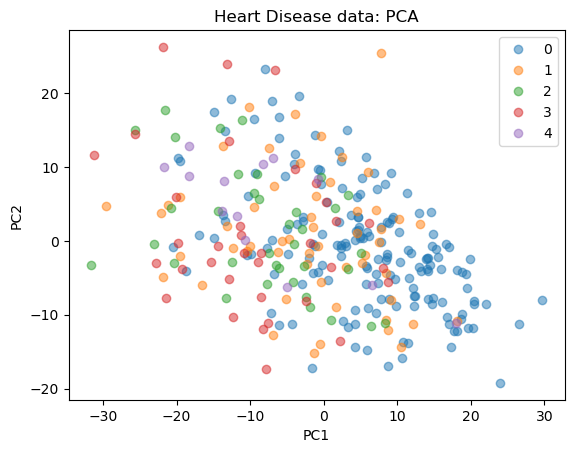

In [13]:
Y = df['num'].to_numpy()

V = Vh.T

Z = X_ @ V

classNames = [0,1,2,3,4]

C = len(classNames)
# Indices of the principal components to be plotted
i = 0
j = 1

# Plot PCA of the data
f = plt.figure()
plt.title("Heart Disease data: PCA")
# Z = array(Z)
for c in range(C):
    # select indices belonging to class c:
    class_mask = Y == c
    plt.plot(Z[class_mask, i], Z[class_mask, j], "o", alpha=0.5)
plt.legend(classNames)
plt.xlabel("PC{0}".format(i + 1))
plt.ylabel("PC{0}".format(j + 1))

# Output result to screen
plt.show()

categorical descision three

In [14]:
import pandas as pd
import numpy as np
import os

# Indlæs data
df = pd.read_csv('null-corrected (1).csv')

# Udtræk attributnavne (antag at kolonne 0 er ID, 1–14 er features, sidste er target)
attributeNames = df.columns[1:15].tolist()
print("Attributter:", attributeNames)

# Udtræk X (features) og y (target)
X = df.iloc[:, 1:-1].to_numpy()  # Kolonner 1 til næstsidste
y = (df['num'] > 0).astype(int)   # Målvariablen


Attributter: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


In [15]:
y = np.array(y)
y

array([0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1,
       1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1,
       0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,

In [16]:
# Standardiser data
N = len(X)
X_ = X - np.ones((N, 1)) * X.mean(axis=0)
X_hat = X_ / X.std(axis=0)  # X_hat er standardiseret version af X


In [17]:
from sklearn.model_selection import train_test_split

# Split data (f.eks. 75% træning, 25% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_hat, y, test_size=0.25, random_state=42, stratify=y
)


Accuracy (test): 0.789


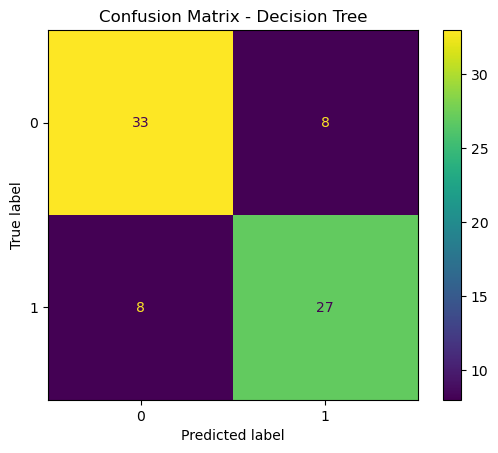

In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Initialisér og træn modellen
model = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
model.fit(X_train, y_train)

# Foruds
y_test_pred = model.predict(X_test)

# Nøjagtighed
acc = accuracy_score(y_test, y_test_pred)
print(f"Accuracy (test): {acc:.3f}")

# Vis confusion matrix
disp = ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.title("Confusion Matrix - Decision Tree")
plt.show()


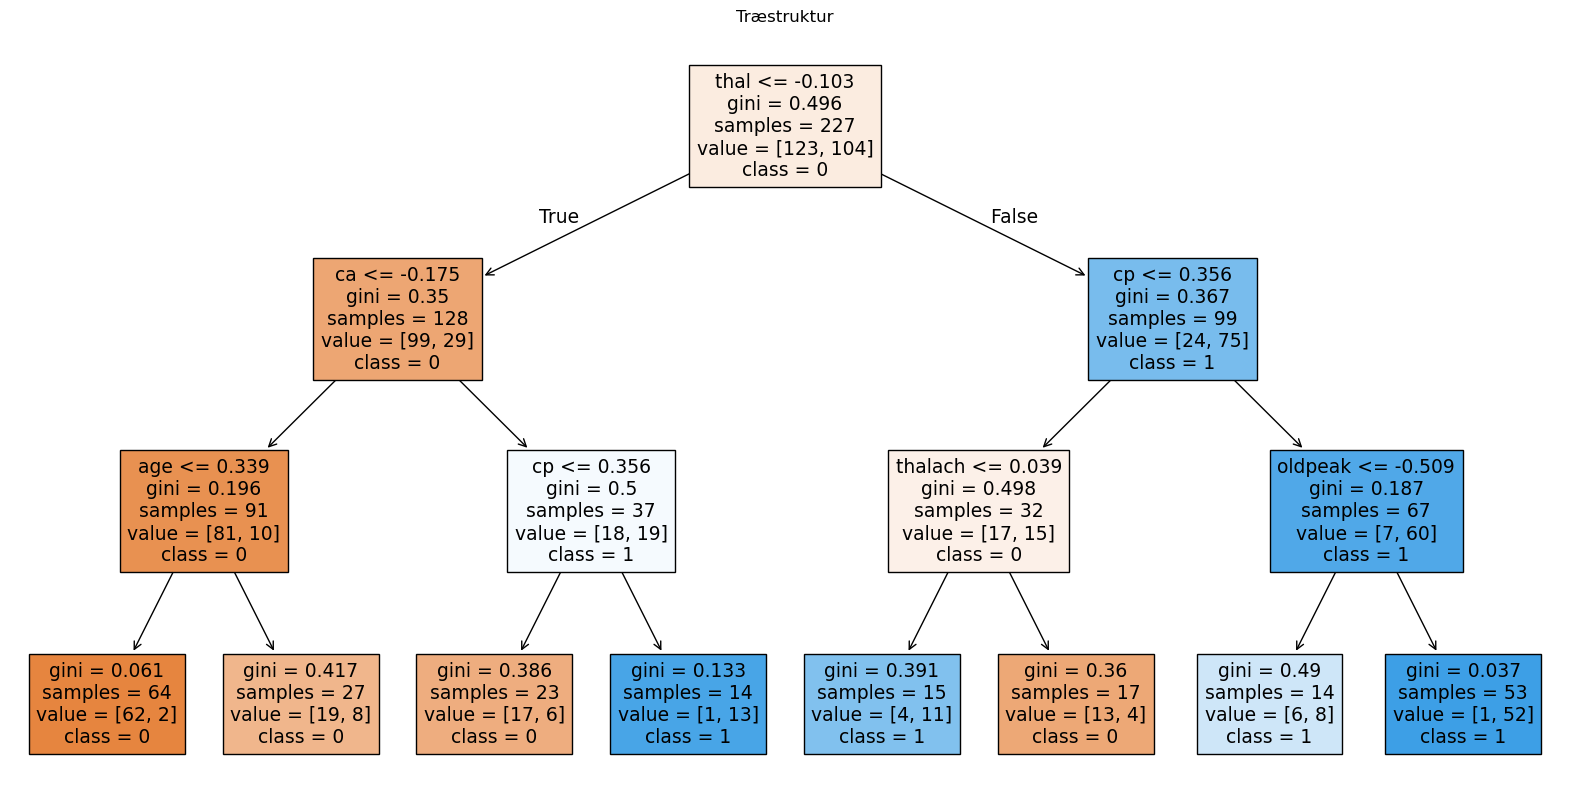

In [19]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(model, feature_names=attributeNames, class_names=[str(i) for i in np.unique(y)], filled=True)
plt.title("Træstruktur")
plt.show()


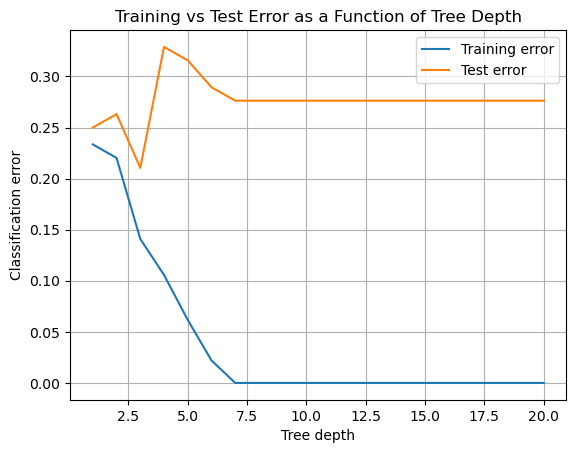

In [20]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

depths = range(1, 21)
train_errors = []
test_errors = []

for depth in depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    
    train_errors.append(1 - train_acc)  # Use error = 1 - accuracy
    test_errors.append(1 - test_acc)

# Plotting
plt.plot(depths, train_errors, label='Training error')
plt.plot(depths, test_errors, label='Test error')
plt.xlabel('Tree depth')
plt.ylabel('Classification error')
plt.title('Training vs Test Error as a Function of Tree Depth')
plt.legend()
plt.grid(True)
plt.show()


two-level cross-validation

In [21]:
from sklearn.model_selection import KFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

# Step 1: Set up outer cross-validation
K1 = 10  # outer folds
CV_outer = KFold(n_splits=K1, shuffle=True, random_state=42)

# Step 2: Define parameter range for method 2 (decision tree)
max_depth_values = [1, 2, 3, 4, 5, 7, 10, None]

# Track results
opt_depths = []
test_errors = []

# Step 3: Outer loop
baseline_errors = []

for i, (train_idx, test_idx) in enumerate(CV_outer.split(X, y)):
    X_train, y_train = X[train_idx], y[train_idx]
    X_test, y_test = X[test_idx], y[test_idx]
    from collections import Counter

    # Compute the most frequent class in training set
    majority_class = Counter(y_train).most_common(1)[0][0]

# Predict that class for all test samples
    y_pred_baseline = np.full_like(y_test, fill_value=majority_class)

# Compute baseline error
    baseline_error = np.mean(y_pred_baseline != y_test)
    baseline_errors.append(baseline_error)
    print(f"Baseline error = {baseline_error:.3f}")


    
    # Step 4: Inner CV to find best max_depth
    inner_cv = KFold(n_splits=5, shuffle=True, random_state=1)
    mean_val_errors = []

    for depth in max_depth_values:
        model = DecisionTreeClassifier(max_depth=depth)
        scores = cross_val_score(model, X_train, y_train, cv=inner_cv, scoring='accuracy')
        val_error = 1 - scores.mean()  # convert accuracy to error
        mean_val_errors.append(val_error)

    # Step 5: Select best parameter
    best_depth = max_depth_values[np.argmin(mean_val_errors)]
    opt_depths.append(best_depth)

    # Step 6: Train on outer train set and evaluate on outer test set
    best_model = DecisionTreeClassifier(max_depth=best_depth)
    best_model.fit(X_train, y_train)
    test_accuracy = best_model.score(X_test, y_test)
    test_error = 1 - test_accuracy
    test_errors.append(test_error)

    # Print fold result
    print(f"Fold {i+1}/{K1}: Best depth = {best_depth}, Test error = {test_error:.3f}")



Baseline error = 0.581
Fold 1/10: Best depth = 3, Test error = 0.097
Baseline error = 0.452
Fold 2/10: Best depth = 3, Test error = 0.258
Baseline error = 0.419
Fold 3/10: Best depth = 4, Test error = 0.323
Baseline error = 0.433
Fold 4/10: Best depth = 3, Test error = 0.100
Baseline error = 0.500
Fold 5/10: Best depth = 3, Test error = 0.167
Baseline error = 0.367
Fold 6/10: Best depth = 3, Test error = 0.200
Baseline error = 0.400
Fold 7/10: Best depth = 3, Test error = 0.233
Baseline error = 0.600
Fold 8/10: Best depth = 3, Test error = 0.167
Baseline error = 0.400
Fold 9/10: Best depth = 4, Test error = 0.333
Baseline error = 0.433
Fold 10/10: Best depth = 7, Test error = 0.167


Logistic regression 

In [22]:
from sklearn.model_selection import train_test_split

# Split data (f.eks. 75% træning, 25% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_hat, y, test_size=0.25, random_state=42, stratify=y
)

Optimal λ = 0.00001
Minimum test error = 0.118


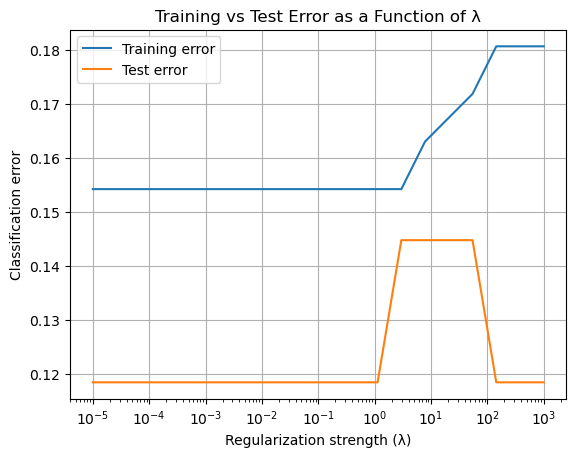

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# Regularization strengths to test (lambda values)
lambda_values = np.logspace(-5, 3, 20)  # 20 values from 1e-5 to 1e3
train_errors = []
test_errors = []

for lam in lambda_values:
    C = 1 / lam  # LogisticRegression uses C = 1 / lambda
    model = LogisticRegression(C=C, solver='liblinear', random_state=42)
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    train_errors.append(1 - train_acc)
    test_errors.append(1 - test_acc)

# Find index of minimum test error
min_index = np.argmin(test_errors)
optimal_lambda = lambda_values[min_index]
optimal_test_error = test_errors[min_index]

print(f"Optimal λ = {optimal_lambda:.5f}")
print(f"Minimum test error = {optimal_test_error:.3f}")

# Plotting
plt.plot(lambda_values, train_errors, label='Training error')
plt.plot(lambda_values, test_errors, label='Test error')
plt.xscale('log')
plt.xlabel('Regularization strength (λ)')
plt.ylabel('Classification error')
plt.title('Training vs Test Error as a Function of λ')
plt.legend()
plt.grid(True)
plt.show()


Accuracy (test): 0.882


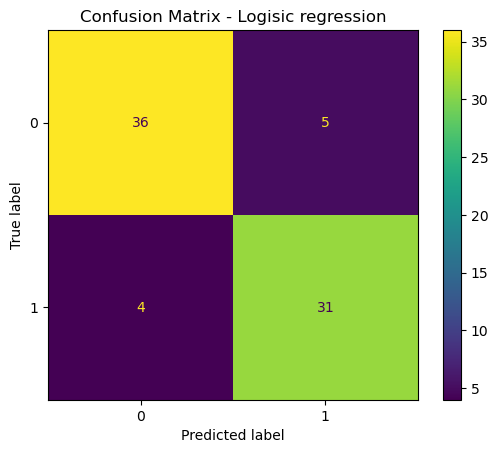

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Initialisér og træn modellen
C = 1/0.00001
model = LogisticRegression(C =C, solver='liblinear', random_state=42)
model.fit(X_train, y_train)

# Foruds
y_test_pred = model.predict(X_test)

# Nøjagtighed
acc = accuracy_score(y_test, y_test_pred)
print(f"Accuracy (test): {acc:.3f}")

# Vis confusion matrix
disp = ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.title("Confusion Matrix - Logisic regression")
plt.show()

In [25]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from collections import Counter
import numpy as np

# Step 1: Set up outer cross-validation
K1 = 10
CV_outer = KFold(n_splits=K1, shuffle=True, random_state=42)

# Step 2: Define parameter range (logistic regression complexity parameter λ)
lambda_values = [10**i for i in range(-5, 4)]  # λ from 1e-5 to 1e3
C_values = [1 / l for l in lambda_values]      # Convert to C = 1/λ

# Track results
opt_Cs = []
test_errors = []
baseline_errors = []

# Step 3: Outer loop
for i, (train_idx, test_idx) in enumerate(CV_outer.split(X, y)):
    X_train, y_train = X[train_idx], y[train_idx]
    X_test, y_test = X[test_idx], y[test_idx]

    # Baseline: majority class prediction
    majority_class = Counter(y_train).most_common(1)[0][0]
    y_pred_baseline = np.full_like(y_test, fill_value=majority_class)
    baseline_error = np.mean(y_pred_baseline != y_test)
    baseline_errors.append(baseline_error)

    # Step 4: Inner CV to find best C
    inner_cv = KFold(n_splits=5, shuffle=True, random_state=1)
    mean_val_errors = []

    for C in C_values:
        model = LogisticRegression(C=C, solver='liblinear', random_state=42)
        scores = cross_val_score(model, X_train, y_train, cv=inner_cv, scoring='accuracy')
        val_error = 1 - scores.mean()
        mean_val_errors.append(val_error)

    # Step 5: Select best C
    best_C = C_values[np.argmin(mean_val_errors)]
    opt_Cs.append(best_C)

    # Step 6: Train on outer training set with best C and evaluate on test set
    best_model = LogisticRegression(C=best_C, solver='liblinear', random_state=42)
    best_model.fit(X_train, y_train)
    y_test_pred = best_model.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_error = 1 - test_accuracy
    test_errors.append(test_error)

    # Print fold result
    best_lamda = 1/best_C
    print(f"Fold {i+1}/{K1}: Best lamda = {best_lamda:.6f}, Test error = {test_error:.3f}, Baseline error = {baseline_error:.3f}")

# Optional summary
print("\nMean test error (LogReg):", np.mean(test_errors))
print("Mean baseline error:", np.mean(baseline_errors))


Fold 1/10: Best lamda = 0.100000, Test error = 0.097, Baseline error = 0.581
Fold 2/10: Best lamda = 10.000000, Test error = 0.097, Baseline error = 0.452
Fold 3/10: Best lamda = 10.000000, Test error = 0.226, Baseline error = 0.419
Fold 4/10: Best lamda = 1.000000, Test error = 0.133, Baseline error = 0.433
Fold 5/10: Best lamda = 0.000010, Test error = 0.200, Baseline error = 0.500
Fold 6/10: Best lamda = 0.000010, Test error = 0.100, Baseline error = 0.367
Fold 7/10: Best lamda = 0.000010, Test error = 0.233, Baseline error = 0.400
Fold 8/10: Best lamda = 0.000010, Test error = 0.167, Baseline error = 0.600
Fold 9/10: Best lamda = 10.000000, Test error = 0.167, Baseline error = 0.400
Fold 10/10: Best lamda = 0.100000, Test error = 0.200, Baseline error = 0.433

Mean test error (LogReg): 0.1619354838709677
Mean baseline error: 0.4584946236559141


Statistical comparison

In [26]:
#CT
best_a = DecisionTreeClassifier(max_depth=3, random_state=42)
best_a.fit(X, y)

y_pred_a = best_a.predict(X)
y_pred_a

array([0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0,
       0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1,

In [27]:
#LR
from sklearn.linear_model import LogisticRegression
C = 1/0.00001

best_b = LogisticRegression(C =C, solver='liblinear', random_state=42)
best_b.fit(X, y)

y_pred_b = best_b.predict(X)
y_pred_b 
len(y_pred_b)

303

In [28]:
y_pred_b == y_pred_a

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True, False,  True,  True,
        True,  True,  True, False, False,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True, False, False,  True,  True,  True,  True, False,
        True,  True, False,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True, False,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,

In [29]:
# baseline 

# Baseline – always predicts class 0 (majority class)
import numpy as np

# Create a baseline "model"
y_pred_baseline = np.zeros_like(y)

y_pred_baseline
print(len(y_pred_baseline))

303


In [30]:
from dtuimldmtools import mcnemar

# Compute the Jeffreys interval
alpha = 0.05
[thetahat, CI, p] = mcnemar(y, y_pred_a, y_pred_b, alpha=alpha)

Result of McNemars test using alpha= 0.05
Comparison matrix n
[[245.  14.]
 [ 13.  31.]]
Approximate 1-alpha confidence interval of theta: [thetaL,thetaU] =  (-0.030253511041782977, 0.0368505052854089)
p-value for two-sided test A and B have same accuracy (exact binomial test): p= 1.0


In [31]:
from dtuimldmtools import mcnemar

# Compute the Jeffreys interval
alpha = 0.05
[thetahat, CI, p] = mcnemar(y, y_pred_a, y_pred_baseline, alpha=alpha)

Result of McNemars test using alpha= 0.05
Comparison matrix n
[[145. 114.]
 [ 19.  25.]]
Approximate 1-alpha confidence interval of theta: [thetaL,thetaU] =  (0.24720414069248386, 0.378380551079017)
p-value for two-sided test A and B have same accuracy (exact binomial test): p= 1.0551613780244042e-17


In [32]:
from dtuimldmtools import mcnemar

# Compute the Jeffreys interval
alpha = 0.05
[thetahat, CI, p] = mcnemar(y, y_pred_b, y_pred_baseline, alpha=alpha)

Result of McNemars test using alpha= 0.05
Comparison matrix n
[[146. 112.]
 [ 18.  27.]]
Approximate 1-alpha confidence interval of theta: [thetaL,thetaU] =  (0.244688887663556, 0.37434767043050465)
p-value for two-sided test A and B have same accuracy (exact binomial test): p= 8.921023429334677e-18


In [33]:
from scipy.stats import binom


def mcnemar_exact_binomial(n12, n21, alpha=0.05):
    # Total number of discordant pairs
    N = n12 + n21
    m = min(n12, n21)

    # Compute p-value using the exact binomial test
    p_value = 2 * binom.cdf(m, N, 0.5)

    # Interpretation
    print(f"n12 = {n12}, n21 = {n21}")
    print(f"Test statistic m = {m}, N = {N}")
    print(f"Exact binomial p-value = {p_value:.5f}")

    if p_value < alpha:
        print("→ Reject H0: There is a significant difference between the models.")
    else:
        print("→ Fail to reject H0: No significant difference between the models.")

    return p_value

mcnemar_exact_binomial(n12=14, n21=13)


n12 = 14, n21 = 13
Test statistic m = 13, N = 27
Exact binomial p-value = 1.00000
→ Fail to reject H0: No significant difference between the models.


1.0